<div style="border: 5px solid purple; padding: 15px; margin: 5px">
<b> Reviewer's comment 2</b>
    
Thank you very much for sending a new version!  I've left a few comments titled as **Reviewer's comment 2**, but there are no issues that need your attention. 

Your project has passed code review. Congratulations 😊


<hr>
   
✍️ Here's a nice playlist [Introduction to
Deep Learning](https://www.youtube.com/playlist?list=PLtBw6njQRU-rwp5__7C0oIVt26ZgjG9NI) on youtube that you may find helpful and interesting. This is another interesting [Computer Vision Playlist](https://www.youtube.com/playlist?list=PLf7L7Kg8_FNxHATtLwDceyh72QQL9pvpQ).     
    
    
Here's a link to [AI for beginners](https://github.com/microsoft/ai-for-beginners) course by Microsoft. 
    
<hr>
    
I hope you enjoyed this topic. Good luck! 
    
Good luck! 😊 
      
</div>

<div style="border: 5px solid purple; padding: 15px; margin: 5px">
<b> Reviewer's comment</b>
    
Hi! My name is Svetlana (https://hub.tripleten.com/u/855fe797). 



It looks like the draft version was submitted. Would you please make sure you upload the correct notebook? 
    
<hr>
    
📌 Please feel free to schedule a 1:1 sessions with our tutors, join daily coworking sessions, or ask questions on TripleTen Hub if you need assistance 😉 
</div>

## Initialization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

from PIL import Image
import os
import matplotlib.patheffects as pe

## Load Data

The dataset is stored in the `/datasets/faces/` folder, there you can find
- The `final_files` folder with 7.6k photos
- The `labels.csv` file with labels, with two columns: `file_name` and `real_age`

Given the fact that the number of image files is rather high, it is advisable to avoid reading them all at once, which would greatly consume computational resources. We recommend you build a generator with the ImageDataGenerator generator. This method was explained in Chapter 3, Lesson 7 of this course.

The label file can be loaded as an usual CSV file.

In [2]:
labels_df = pd.read_csv('/datasets/faces/labels.csv')

train_datagen = ImageDataGenerator(rescale=1./255)

train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory='/datasets/faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        seed=12345)

## EDA

In [3]:
labels_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


In [4]:
print(labels_df.isna().sum())

file_name    0
real_age     0
dtype: int64


In [5]:
print(labels_df['file_name'].nunique())

7591


In [6]:
print(labels_df.shape)

(7591, 2)


In [7]:
print(labels_df['real_age'].min())
print(labels_df['real_age'].max())

1
100


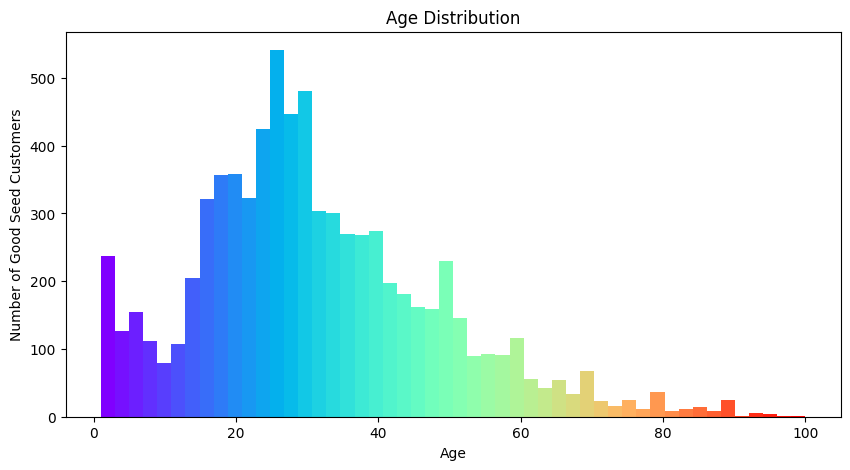

In [8]:
real_ages = labels_df['real_age']

plt.figure(figsize=(10, 5))
counts, bins, patches = plt.hist(real_ages, bins=50)

for patch, color in zip(patches, plt.cm.rainbow(np.linspace(0,1,len(patches)))):
    patch.set_facecolor(color)
    
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Good Seed Customers')
plt.show()

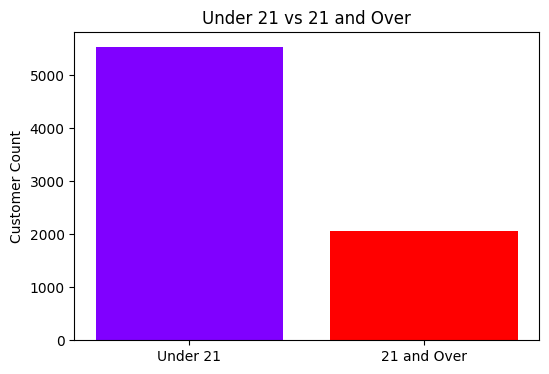

In [9]:
legal_age = labels_df['real_age'] >= 21
under_age = labels_df['real_age'] < 21

group_count= [
    legal_age.sum(),
     under_age.sum()]

categories=['Under 21','21 and Over']

colors=plt.cm.rainbow(np.linspace(0, 1, len(categories)))

plt.figure(figsize=(6, 4))
plt.bar(categories, group_count, color=colors)
plt.title('Under 21 vs 21 and Over')
plt.ylabel('Customer Count')
plt.show()

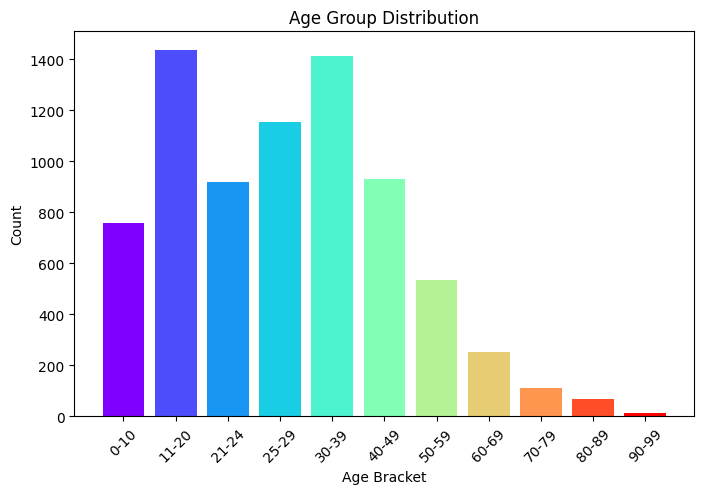

In [10]:
age_grouping = pd.cut(
    labels_df['real_age'],
    bins=[0, 11, 21, 25, 30, 40, 50, 60, 70, 80, 90, 100],
    labels=['0-10','11-20','21-24','25-29','30-39','40-49','50-59', '60-69','70-79','80-89','90-99']
)

age_grouping= age_grouping.value_counts().sort_index()
colors=plt.cm.rainbow(np.linspace(0, 1, len(age_grouping)))

plt.figure(figsize=(8,5))
plt.bar(age_grouping.index, age_grouping.values, color=colors)
plt.title('Age Group Distribution')
plt.xlabel('Age Bracket')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

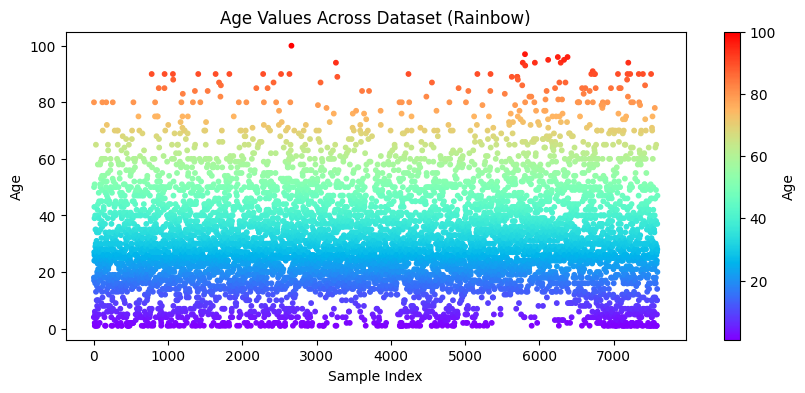

In [11]:
plt.figure(figsize=(10, 4))

plt.scatter(
    range(len(labels_df)),
    labels_df['real_age'],
    c=labels_df['real_age'],
    cmap='rainbow',
    s=10
)

plt.colorbar(label='Age')
plt.title('Age Values Across Dataset (Rainbow)')
plt.xlabel('Sample Index')
plt.ylabel('Age')
plt.show()

In [ ]:
age_ranges = {
    'Children (0-12)': (0, 12),
    'Teens (13-19)': (13, 19),
    'Young Adults (21-29)': (21, 29),
    'Adults (30-39)': (30, 39),
    'Middle Age (40-59)': (40, 59),
    'Seniors (60-79)': (60, 79),
    'Experienced (80-100)': (80, 100)
}

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Sample Images from Different Age Groups', fontsize=16)

sample_count = 0
total_slots = 15
images_path = '/datasets/faces/final_files/'
colors = plt.cm.rainbow(np.linspace(0, 1, total_slots))

for age_group, (min_age, max_age) in age_ranges.items():
    age_subset = labels_df[(labels_df['real_age'] >= min_age) &
                           (labels_df['real_age'] <= max_age)]

    if len(age_subset) > 0:
        samples = age_subset.sample(min(2, len(age_subset)), random_state=42)

        for _, row in samples.iterrows():
            if sample_count >= total_slots:
                break

            img_path = os.path.join(images_path, row['file_name'])
            img = Image.open(img_path)

            row_idx = sample_count // 5
            col_idx = sample_count % 5

            ax = axes[row_idx, col_idx]
            ax.imshow(img)

            ax.set_title(f"{age_group}\nAge: {row['real_age']}",
                         color=colors[sample_count], fontsize=14)

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_frame_on(True)

            for spine in ax.spines.values():
                spine.set_edgecolor(colors[sample_count])
                spine.set_linewidth(6)
            sample_count += 1

for i in range(sample_count, total_slots):
    row_idx = i // 5
    col_idx = i % 5
    axes[row_idx, col_idx].axis('off')
plt.subplots_adjust(top=0.88, wspace=0.25, hspace=0.35)
plt.show()

### Findings

After the data analysis, these were the findings:
* The dataset consisted of 2 columns and 7,591 entries in total.
* There was no missing data and no duplicates were found.
* The data frame shape was 7591, 2 
* The youngest shopper was 1 year and the oldest shopper was 100 years old.
* Shoppers between the ages of 1 and 60 made up the majority of customers. 
* The number of customers under the age of 21 were well over double the number of customers that were 21 and older.
* The group with 11-20 years of age was the most active. 
* The age group with 30-39 years old came in second.
* Customers between the age of 25-29 years were the third most active.
* The least active customers were between the ages of 90-99, followed by 80-89, and then 70-79.
* Looking at the scatter plot we can see that age is well distributed throughout the data.

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment 2 </b>
    
Great job here! 
</div>

## Modelling

Define the necessary functions to train your model on the GPU platform and build a single script containing all of them along with the initialization section.

To make this task easier, you can define them in this notebook and run a ready code in the next section to automatically compose the script.

The definitions below will be checked by project reviewers as well, so that they can understand how you built the model.

In [ ]:
def load_train(path):
    
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=.25)
    
    labels_df = pd.read_csv('/datasets/faces/labels.csv')
    
    train_datagen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels_df,
        directory='/datasets/faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(150, 150),
        batch_size=16,
        class_mode='raw',
        subset='training',
        shuffle=True,
        seed=12345)

    return train_datagen_flow

In [ ]:
def load_test(path):
    test_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.25)
    
    labels_df = pd.read_csv('/datasets/faces/labels.csv')
    
    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=labels_df,
        directory='/datasets/faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(150, 150),
        batch_size=16,
        class_mode='raw',
        subset='validation',
        shuffle=False,
        seed=12345)
    
    return test_gen_flow 

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>

- It's great that you specify the `subset` parameter values. If we don't do this, the model will be trained and evaluated on the same data. 
    

- The `class_mode` value is also correct. 

</div>
<div style="border: 5px solid gold; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
    
I recommend using some variable for `seed`. 

</div>

In [ ]:
def create_model(input_shape):
    
    backbone = ResNet50(weights='imagenet', 
                        input_shape=input_shape,
                        include_top=False)

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))

    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    return model

<div style="border: 5px solid green; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>


Correct! 
    
    
- `Dense(1, activation='relu')` is appropriate, since you are predicting a single value. Using 1 neuron makes sense here.
    
    
    
- Adam optimizer is a solid and commonly used choice, well done. 


- The use of MSE loss and MAE as metric is also correct. MSE encourages precision, and MAE helps us interpret error scale in the same units as the target.

</div>

In [ ]:
def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):

    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)
        
    if validation_steps is None:
        validation_steps = len(test_data)

    model.fit(train_data, 
              validation_data=test_data,
              batch_size=batch_size, epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2)

    return model


### Prepare the Script to Run on the GPU Platform

Given you've defined the necessary functions you can compose a script for the GPU platform, download it via the "File|Open..." menu, and to upload it later for running on the GPU platform.

N.B.: The script should include the initialization section as well. An example of this is shown below.

In [ ]:
init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    
    f.write(init_str)
    f.write('\n\n')
        
    for fn_name in [load_train, load_test, create_model, train_model]:
        
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')

### Output

Place the output from the GPU platform as an Markdown cell here.

Epoch 1/20
356/356 - 35s - loss: 95.3532 - mae: 7.4339 - val_loss: 124.3362 - val_mae: 8.4921
Epoch 2/20
356/356 - 35s - loss: 76.8372 - mae: 6.6707 - val_loss: 127.6357 - val_mae: 8.6035
Epoch 3/20
356/356 - 35s - loss: 69.9428 - mae: 6.3992 - val_loss: 91.1531 - val_mae: 7.4454
Epoch 4/20
356/356 - 35s - loss: 64.4249 - mae: 6.1407 - val_loss: 124.0287 - val_mae: 8.3481
Epoch 5/20
356/356 - 35s - loss: 52.8486 - mae: 5.5913 - val_loss: 109.1004 - val_mae: 8.2192
Epoch 6/20
356/356 - 35s - loss: 46.3094 - mae: 5.2223 - val_loss: 85.1038 - val_mae: 7.0332
Epoch 7/20
356/356 - 35s - loss: 38.2617 - mae: 4.7951 - val_loss: 92.0900 - val_mae: 7.3359
Epoch 8/20
356/356 - 35s - loss: 37.4804 - mae: 4.7402 - val_loss: 80.0016 - val_mae: 6.7239
Epoch 9/20
356/356 - 35s - loss: 33.5237 - mae: 4.4271 - val_loss: 83.2579 - val_mae: 6.8529
Epoch 10/20
356/356 - 35s - loss: 28.5170 - mae: 4.1411 - val_loss: 83.5056 - val_mae: 6.9629
Epoch 11/20
356/356 - 35s - loss: 27.0142 - mae: 3.9700 - val_loss: 92.1290 - val_mae: 7.1866
Epoch 12/20
356/356 - 35s - loss: 27.4564 - mae: 4.0428 - val_loss: 185.6307 - val_mae: 11.4591
Epoch 13/20
356/356 - 35s - loss: 23.7961 - mae: 3.7407 - val_loss: 92.3429 - val_mae: 7.2467
Epoch 14/20
356/356 - 35s - loss: 24.6167 - mae: 3.8116 - val_loss: 92.4542 - val_mae: 7.1401
Epoch 15/20
356/356 - 35s - loss: 22.2604 - mae: 3.6746 - val_loss: 82.5822 - val_mae: 6.7841
Epoch 16/20
356/356 - 35s - loss: 20.1899 - mae: 3.4430 - val_loss: 86.3830 - val_mae: 6.8304
Epoch 17/20
356/356 - 35s - loss: 17.3425 - mae: 3.2205 - val_loss: 78.4369 - val_mae: 6.6419
Epoch 18/20
356/356 - 35s - loss: 16.5249 - mae: 3.1295 - val_loss: 81.7731 - val_mae: 6.7226
Epoch 19/20
356/356 - 35s - loss: 16.6140 - mae: 3.1421 - val_loss: 80.9727 - val_mae: 6.9908
Epoch 20/20
356/356 - 35s - loss: 17.0187 - mae: 3.1785 - val_loss: 93.4115 - val_mae: 7.6512

<div style="border: 5px solid gold; padding: 15px; margin: 5px">
<b> Reviewer's comment</b>
   

Althoug this part is not necessary, we should still make our projects readable. You can use Markdown cells for your code and results: 

    ```python
    
    # code
    # or the output
    
    ```
    
Example:
    
</div>


```python

import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50


...



Epoch 1/20
356/356 - 35s - loss: 95.3532 - mae: 7.4339 - val_loss: 124.3362 - val_mae: 8.4921              
```

## Conclusions

After reviewing the model results, its clear that with an MAE of more than 7 years this model is not a sufficient tool for measure whether or not some is 21 or over. The margin  of error is too great to solely rely on this model. However, there are other potential applications that this model could be used for, beyond alcohol sales. 
* Use as a decision support tool, especially for busy times
* Analyze foot traffic and demographics throughout the day.
* Promotion of products to predominate age groups and displaying age appropriate ads on digital screens near checkout.
* Improve overall advertisement targeting without collecting personal data.
* Flag customers whose estimated age is close to the legal threshold for alcohol and other age restricted products.
* View age distrubution across different stores, if this is a chain.


Again, i do want to re-iterate, that this tool should not be used alone to verify whether or not a person is of age in order to purchase alcohol, as this would be an unethical practice due to the over 7 year margin of error.

<div style="border: 5px solid green; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    
    
Although the model shows small overfitting, it is still good. We can still think about further improvements. Sometimes it is possible to increase the dataset. What else can be done? Sometimes it may be helpful to try different data augmentation approaches. By the way, here's a good library [albumentations](https://github.com/albumentations-team/albumentations). Apart from this, we can consider introducing additional layers with some normalization methods. The optimization part is good. Adam is quite flexible, but you can still try other optimizers if you want. For example, AdamW sometimes shows better results. 



Regarding age verification, I would argue that we have some noticable limits here. It is much more reliable and much easier to just compare the id or passport photo to the customer's face. 

</div>

# Checklist

- [ ]  Notebook was opened
- [ ]  The code is error free
- [ ]  The cells with code have been arranged by order of execution
- [ ]  The exploratory data analysis has been performed
- [ ]  The results of the exploratory data analysis are presented in the final notebook
- [ ]  The model's MAE score is not higher than 8
- [ ]  The model training code has been copied to the final notebook
- [ ]  The model training output has been copied to the final notebook
- [ ]  The findings have been provided based on the results of the model training